# Appropriateness and Harm Scoring

**Goal.** Turn each raw test recommendation into a structured score on two axes -
**appropriateness** (is this the right test now, or redundant / off-protocol / low-yield?)
and **harm/burden** (radiation, invasiveness, cost) - so the delivery policy has something
to reason about.

## Pipeline

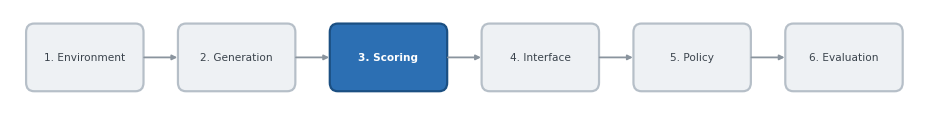

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
from shared.diagrams import draw_pipeline, draw_stage_io
draw_pipeline(active='scoring');

## Prior work and limitations

- **Park et al. 2022.** Alert *appropriateness* drives whether physicians act on CDS - the
  metric we score.
- **Müskens et al. 2022.** Overuse of diagnostic testing is systemic; low-yield tests carry
  real cost and harm.
- **Baron et al. 2021.** ML to flag duplicate/low-value test alerts and cut alert burden.
- **Wu et al. 2025 (NOHARM).** Framework for clinically safe LLMs - motivates an explicit
  harm axis, not just accuracy.

## Approach

Prior CDS work scores alerts mostly **after the fact** (was this alert appropriate?). We score
each recommendation **at generation time**, before deciding to deliver it:

- A transparent, rule-based score (appropriateness, harm, redundancy) that runs offline and is
  easy to audit - plus an optional **LLM appropriateness rubric** mirroring CDS studies.
- Harm is modeled explicitly (radiation/contrast/invasiveness/cost), not folded into a single
  accuracy number.
- The output is the **context vector** the contextual bandit (Stage 05) learns from.

## Mechanism

**Input:** a case, a proposed test, and the set of already-ordered tests.
**Output:** `{appropriateness in [0,1], harm in [0,1], cost, redundant, rationale}`.

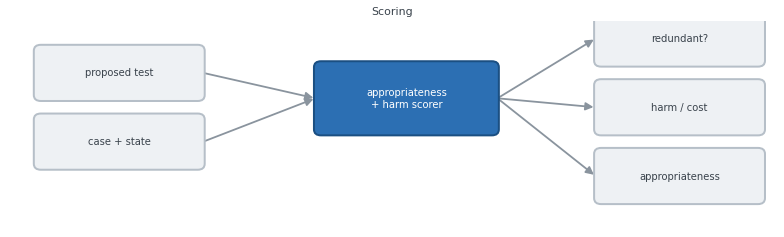

In [2]:
draw_stage_io('Scoring', ['case + state', 'proposed test'], 'appropriateness\n+ harm scorer',
              ['appropriateness', 'harm / cost', 'redundant?']);

## Walkthrough
### 1. Score a range of recommendations
*Expected output:* the confirmatory test scores high appropriateness **and** high harm (it is
a contrast CT); a repeat test is flagged redundant; an off-protocol test scores low.

In [3]:
from shared.toy_data import load_case
from demo_scoring import score_recommendation
case = load_case('PE-2180')
ordered = {'D-Dimer'}  # pretend this was already ordered
print(f"{'test':<26}{'appr':>6}{'harm':>6}{'cost':>7}  rationale")
for test in ['CT pulmonary angiogram', 'D-Dimer', 'Chest radiograph', 'Troponin', 'MRI brain']:
    s = score_recommendation(case, test, ordered)
    print(f"{test:<26}{s.appropriateness:>6.2f}{s.harm:>6.2f}${s.cost:>6.0f}  {s.rationale}")

test                        appr  harm   cost  rationale
CT pulmonary angiogram      0.88  0.87$   500  Discriminates the leading differential; high diagnostic yield.
D-Dimer                     0.05  0.11$    40  Duplicate: this test was already ordered (Baron 2021).
Chest radiograph            0.40  0.47$    60  Plausible but low-yield given the current findings (overuse risk).
Troponin                    0.40  0.11$    40  Plausible but low-yield given the current findings (overuse risk).
MRI brain                   0.30  0.40$    50  Off-protocol / not a recognized test for this presentation.


### 2. The appropriateness/harm trade-off
*Expected output:* a scatter where the useful confirmatory test sits high on **both** axes -
exactly the tension the delivery policy must manage (high value, but burdensome).

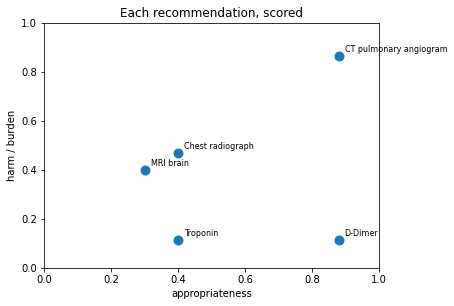

In [4]:
import matplotlib.pyplot as plt
tests = ['CT pulmonary angiogram', 'D-Dimer', 'Chest radiograph', 'Troponin', 'MRI brain']
scores = [score_recommendation(case, t) for t in tests]
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter([s.appropriateness for s in scores], [s.harm for s in scores], s=80)
for t, s in zip(tests, scores):
    ax.annotate(t, (s.appropriateness, s.harm), textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xlabel('appropriateness'); ax.set_ylabel('harm / burden')
ax.set_title('Each recommendation, scored'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.show()

### 3. Optional: LLM appropriateness rubric (1-5)
*Expected output (real model only):* an integer 1-5; returns `None` under the offline stub.

In [5]:
from demo_scoring import llm_appropriateness
rating = llm_appropriateness(case, 'CT pulmonary angiogram', 'elevated D-dimer, tachycardia')
print('LLM appropriateness (1-5):', rating)

LLM appropriateness (1-5): 5


**Next:** Notebook 04 delivers a scored recommendation to a simulated clinician and models
whether it is accepted - including alert fatigue.